# Global COVID-19 Country Snapshot Analysis

**Scope:** 187 countries across six WHO regions, reported as of July 27, 2020  
**Goal:** compare regional burden and outcomes, identify outliers, and validate the source before drawing conclusions.

### Summary

- The snapshot contains **16.48 million confirmed cases**, including **654,036 deaths** and **9.47 million recoveries**.
- The **Americas represented 53.6%** of confirmed cases. Europe had the highest regional case fatality rate at **6.40%**.
- South-East Asia recorded the fastest weighted one-week growth at **24.15%**.
- Among countries with at least 1,000 confirmed cases, Zimbabwe had the highest weekly percentage increase at **57.85%**.

This notebook emphasizes reproducibility and careful interpretation. All rates are calculated from aggregated counts and countries with very few cases were left out of the growth rankings as small increases can make their percentage growth look misleadingly large.


## 1. Questions

1. Is the dataset complete, unique at the country level, and internally consistent?
2. How are confirmed cases distributed across WHO regions?
3. How do regional fatality, recovery, active-case, and weekly growth rates compare?
4. Which countries report the largest totals and fastest recent growth?
5. What can, and cannot, be concluded from this data?


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
from src.analysis import build_global_summary, build_regional_summary, rank_countries, validate_data

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {"navy": "#16324F", "blue": "#2C7FB8", "teal": "#2A9D8F", "gold": "#E9C46A", "red": "#D95F59"}
pd.set_option("display.max_columns", 20)


## 2. Data Loading

The source is a snapshot rather than a daily time series. Each row represents one country or territory.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "country_wise_latest.csv"
data = pd.read_csv(DATA_PATH)

print(f"Rows: {data.shape[0]:,} | Columns: {data.shape[1]}")
data.head()

Rows: 187 | Columns: 15


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


### Field groups

- **Cumulative counts:** `Confirmed`, `Deaths`, `Recovered`, `Active`
- **Latest reported changes:** `New cases`, `New deaths`, `New recovered`
- **Comparisons (over a week):** `Confirmed last week`, `1 week change`, `1 week % increase`
- **Grouping:** `Country/Region`, `WHO Region`

The source also provides precomputed ratios. This analysis recalculates important regional rates from counts to ensure proper weighting.


## 3. Data-quality audit

In [3]:
audit = validate_data(data)
pd.DataFrame(
    {
        "Check": ["Rows", "Columns", "Missing values", "Duplicate countries", "Case identity failures"],
        "Result": [audit["rows"], audit["columns"], audit["missing_values"], audit["duplicate_countries"], audit["case_identity_failures"]],
        "Expected": [187, 15, 0, 0, 0],
    }
)

,Check,Result,Expected
0,Rows,187,187
1,Columns,15,15
2,Missing values,0,0
3,Duplicate countries,0,0
4,Case identity failures,0,0


All five checks pass. In particular, every record satisfies:

$$\text{Confirmed} = \text{Deaths} + \text{Recovered} + \text{Active}$$

This confirms arithmetic consistency, however it does not prove that reported counts are complete or comparable across countries.


## 4. Global snapshot

In [4]:
global_summary = build_global_summary(data)
global_display = pd.DataFrame({"Metric": global_summary.index, "Value": global_summary.values})
global_display["Value"] = global_display.apply(
    lambda row: f"{row['Value']:,.2f}%" if "rate" in row["Metric"].lower() else f"{row['Value']:,.0f}",
    axis=1,
)
global_display

,Metric,Value
0,Countries,187
1,Confirmed cases,"16,480,485"
2,Deaths,"654,036"
3,Recovered,"9,468,087"
4,Active cases,"6,358,362"
5,One-week growth rate (%),12.01%
6,Case fatality rate (%),3.97%


## 5. Regional comparison

Rates below are **weighted**: counts are summed within each region before dividing. This is more appropriate than averaging country percentages, which would give a small country the same influence as a large one.


In [5]:
regional = build_regional_summary(data)
regional_table = regional[[
    "WHO Region", "countries", "confirmed", "deaths", "case_share_pct",
    "fatality_pct", "recovery_pct", "active_pct", "weekly_growth_pct"
]].copy()
regional_table.columns = [
    "WHO Region", "Countries", "Confirmed", "Deaths", "Case share (%)",
    "Fatality (%)", "Recovery (%)", "Active (%)", "Weekly growth (%)"
]
regional_table.round(2)

,WHO Region,Countries,Confirmed,Deaths,Case share (%),Fatality (%),Recovery (%),Active (%),Weekly growth (%)
0,Americas,35,8839286,342732,53.63,3.88,50.55,45.57,13.10
1,Europe,56,3299523,211144,20.02,6.40,60.42,33.18,4.85
2,South-East Asia,10,1835297,41349,11.14,2.25,63.04,34.71,24.15
3,Eastern Mediterranean,22,1490744,38339,9.05,2.57,80.59,16.84,6.57
4,Africa,48,723207,12223,4.39,1.69,60.93,37.38,18.93
5,Western Pacific,16,292428,8249,1.77,2.82,70.71,26.47,9.79


/var/folders/xn/vtg0wd3j02zbwdkmk7mqzdtw0000gn/T/ipykernel_7410/1945454922.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  rate_plot["Measure"] = rate_plot["Measure"].map({
/Users/caleb/Downloads/covid19-country-analysis/.venv/lib/pytho

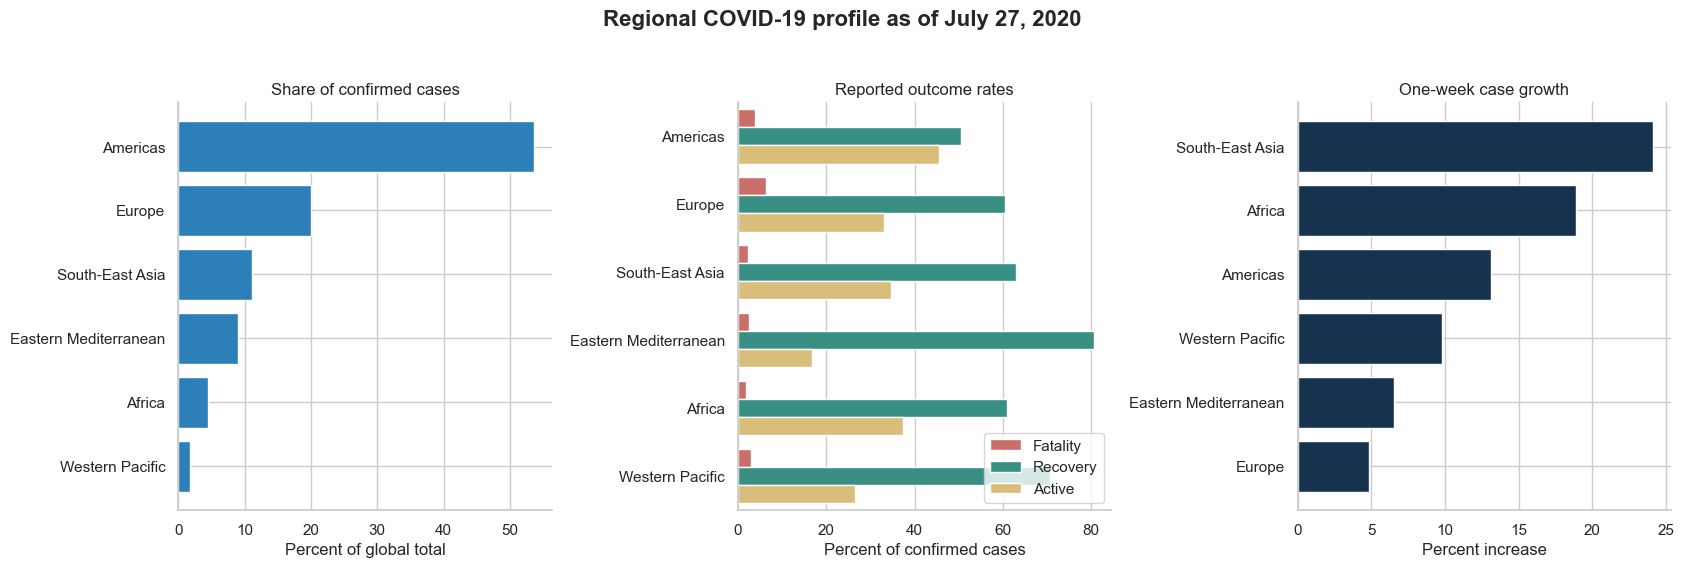

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
order = regional.sort_values("confirmed", ascending=True)

axes[0].barh(order["WHO Region"], order["case_share_pct"], color=COLORS["blue"])
axes[0].set_title("Share of confirmed cases")
axes[0].set_xlabel("Percent of global total")
axes[0].set_ylabel("")

rate_plot = regional.melt(
    id_vars="WHO Region",
    value_vars=["fatality_pct", "recovery_pct", "active_pct"],
    var_name="Measure",
    value_name="Percent",
)
rate_plot["Measure"] = rate_plot["Measure"].map({
    "fatality_pct": "Fatality", "recovery_pct": "Recovery", "active_pct": "Active"
})
sns.barplot(data=rate_plot, y="WHO Region", x="Percent", hue="Measure", ax=axes[1], palette=[COLORS["red"], COLORS["teal"], COLORS["gold"]])
axes[1].set_title("Reported outcome rates")
axes[1].set_xlabel("Percent of confirmed cases")
axes[1].set_ylabel("")
axes[1].legend(title="", loc="lower right")

growth_order = regional.sort_values("weekly_growth_pct", ascending=True)
axes[2].barh(growth_order["WHO Region"], growth_order["weekly_growth_pct"], color=COLORS["navy"])
axes[2].set_title("One-week case growth")
axes[2].set_xlabel("Percent increase")
axes[2].set_ylabel("")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Regional COVID-19 profile as of July 27, 2020", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
figure_path = PROJECT_ROOT / "reports" / "figures" / "regional_overview.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()


### Regional findings

- The **Americas** accounted for **53.6%** of confirmed cases and 52.4% of deaths.
- **Europe** had the highest reported case fatality rate (**6.40%**), while the **Eastern Mediterranean** had the highest recovery rate (**80.59%**).
- **South-East Asia** had the fastest weighted weekly growth (**24.15%**), followed by **Africa** (**18.93%**).

These values describe reported outcomes in the snapshot. They are not to be interpreted as direct measures of individual risk or health system performance.


## 6. Country-level rankings

In [7]:
top_confirmed = rank_countries(data, "Confirmed")
top_deaths = rank_countries(data, "Deaths")
fastest_growth = rank_countries(data, "1 week % increase", minimum_confirmed=1_000)

fastest_growth[["Country/Region", "WHO Region", "Confirmed", "1 week % increase"]]

,Country/Region,WHO Region,Confirmed,1 week % increase
0,Zimbabwe,Africa,2704,57.85
1,Libya,Eastern Mediterranean,2827,42.78
2,Ethiopia,Africa,14547,42.52
3,Suriname,Americas,1483,37.44
4,Costa Rica,Americas,15841,37.34
5,Namibia,Africa,1843,37.13
6,Zambia,Africa,4552,36.86
7,Madagascar,Africa,9690,35.47
8,Lebanon,Eastern Mediterranean,3882,33.63
9,Montenegro,Europe,2893,32.22


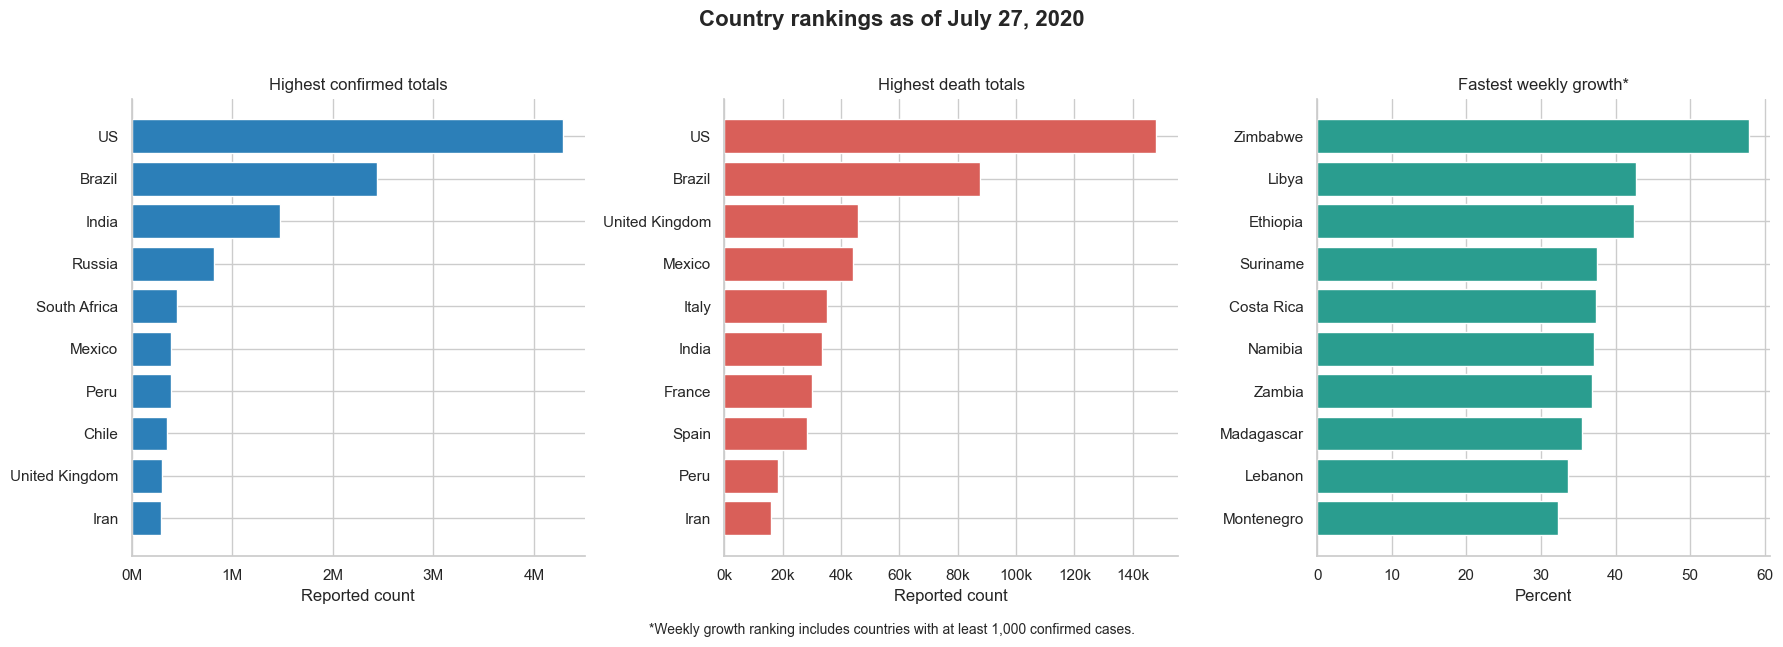

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plots = [
    (top_confirmed.sort_values("Confirmed"), "Confirmed", "Highest confirmed totals", COLORS["blue"]),
    (top_deaths.sort_values("Deaths"), "Deaths", "Highest death totals", COLORS["red"]),
    (fastest_growth.sort_values("1 week % increase"), "1 week % increase", "Fastest weekly growth*", COLORS["teal"]),
]

for ax, (frame, metric, title, color) in zip(axes, plots):
    ax.barh(frame["Country/Region"], frame[metric], color=color)
    ax.set_title(title)
    ax.set_xlabel("Percent" if "%" in metric else "Reported count")
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000_000:.0f}M"))
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1_000:.0f}k"))

fig.suptitle("Country rankings as of July 27, 2020", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.5, -0.02, "*Weekly growth ranking includes countries with at least 1,000 confirmed cases.", ha="center", fontsize=10)
fig.tight_layout()
figure_path = PROJECT_ROOT / "reports" / "figures" / "country_rankings.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

The volume threshold changes the growth story. Without it, the highest percentage increases come from countries with very small starting counts. The 1,000-case cutoff keeps the ranking interpretable while remaining transparent about the chosen rule!


## 7. Relationship between confirmed cases and deaths

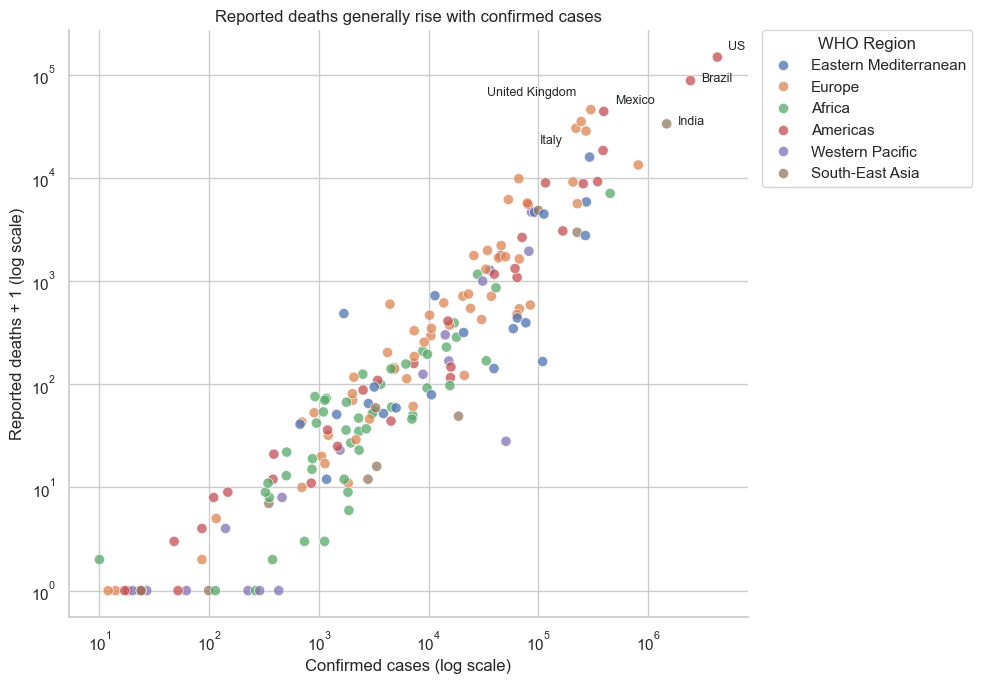

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter_data = data.assign(Deaths_for_log_scale=data["Deaths"] + 1)
sns.scatterplot(
    data=scatter_data,
    x="Confirmed",
    y="Deaths_for_log_scale",
    hue="WHO Region",
    s=55,
    alpha=0.75,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Reported deaths generally rise with confirmed cases")
ax.set_xlabel("Confirmed cases (log scale)")
ax.set_ylabel("Reported deaths + 1 (log scale)")

label_offsets = {
    "US": (8, 5), "Brazil": (8, -1), "United Kingdom": (-75, 10),
    "Mexico": (8, 5), "Italy": (-30, -16), "India": (8, -1),
}
for _, row in data.nlargest(6, "Deaths").iterrows():
    country = row["Country/Region"]
    ax.annotate(
        country,
        (row["Confirmed"], row["Deaths"] + 1),
        xytext=label_offsets[country],
        textcoords="offset points",
        fontsize=9,
    )

ax.legend(title="WHO Region", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
figure_path = PROJECT_ROOT / "reports" / "figures" / "reported_cases_vs_deaths.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

The log-scaled view makes countries of very different sizes visible in one chart. Confirmed cases and deaths move together, but the spread at similar case totals reinforces that a raw bivariate relationship does not simply explain why outcomes differ.

## 8. Conclusions and limitations

This analysis shows that the reported global burden was highly concentrated in the Americas, while regional outcome and growth rates varied substantially. It also demonstrates why aggregation choices matter: Weighted regional rates (so based on total reported cases) and a minimum case requirement for country comparisons produce more defensible comparisons than simple averages or unrestricted percentage rankings.

### Limitations

- Once more the file is a **single snapshot**, not a continuing dataset. It cannot support forecasting or long-term trend analysis.
- Counts are not adjusted for population, age, testing volume, or reporting practices.
- Recovery definitions and reporting frequency were not standardized across countries.
- Observed relationships are descriptive and do not establish causation.

### Possible extensions

1. Join population data to calculate per-capita case and death rates.
2. Add the full daily time series to analyze growth trajectories.
3. Incorporate testing and demographic variables to evaluate reporting and outcome differences more carefully.
